# 02 · Is music like fashion?

**The question:** fashion recurs — flares, then skinny, then flares again. Does music do the same, with themes returning every few decades? We test it on the 100-year timeline (B).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'analysis'))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
from common import load_genre, load_timeline, AUDIO, zscore
df = load_timeline()
zdf = pd.DataFrame(zscore(df), columns=AUDIO).assign(decade=df.decade.values)
by_decade = zdf.groupby('decade')[AUDIO].mean()
print('decades:', list(by_decade.index))

decades: [1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]


## Step 1 — The sound of each decade (heatmap)
Standardized features, decade by decade. Red = high, blue = low. Read it top-to-bottom and watch the color flip around 1970–80: the 'electrification' of music.

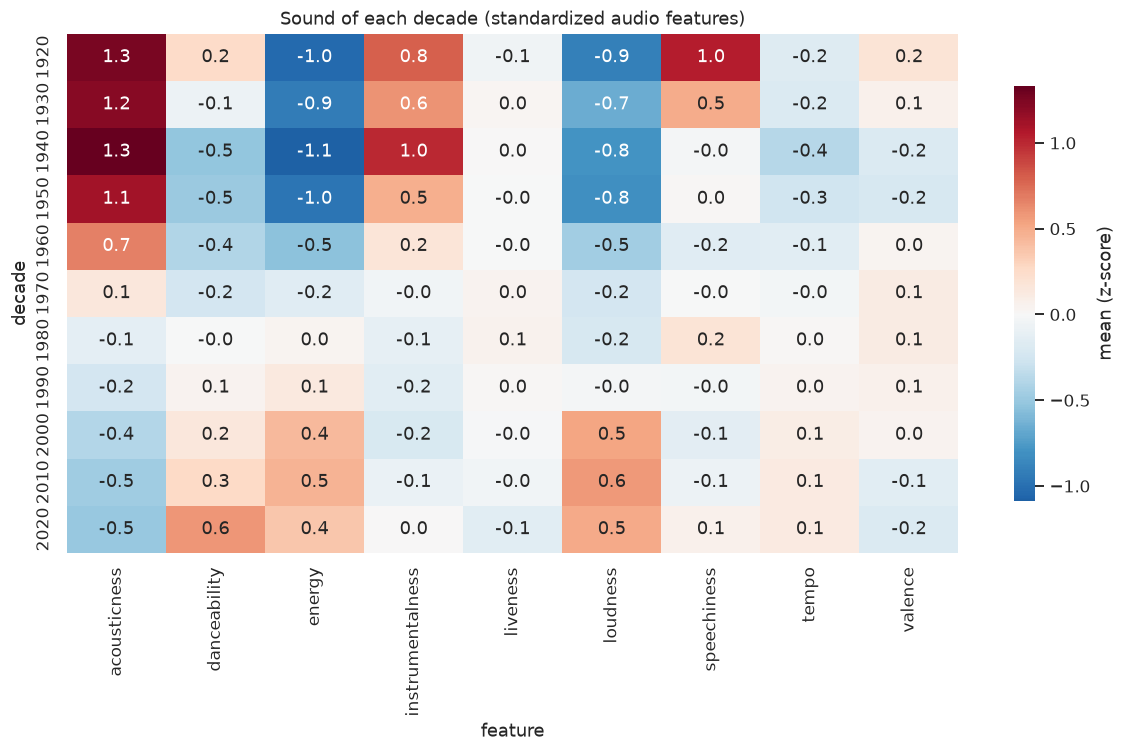

In [2]:
plt.figure(figsize=(11, 7))
sns.heatmap(by_decade, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'mean (z-score)', 'shrink': .8})
plt.title('Sound of each decade (standardized audio features)')
plt.xlabel('feature'); plt.ylabel('decade'); plt.tight_layout(); plt.show()

## Step 2 — Each feature's trajectory (small multiples)
One panel per feature so no line hides another. Most are monotone drifts, not up-and-down cycles.

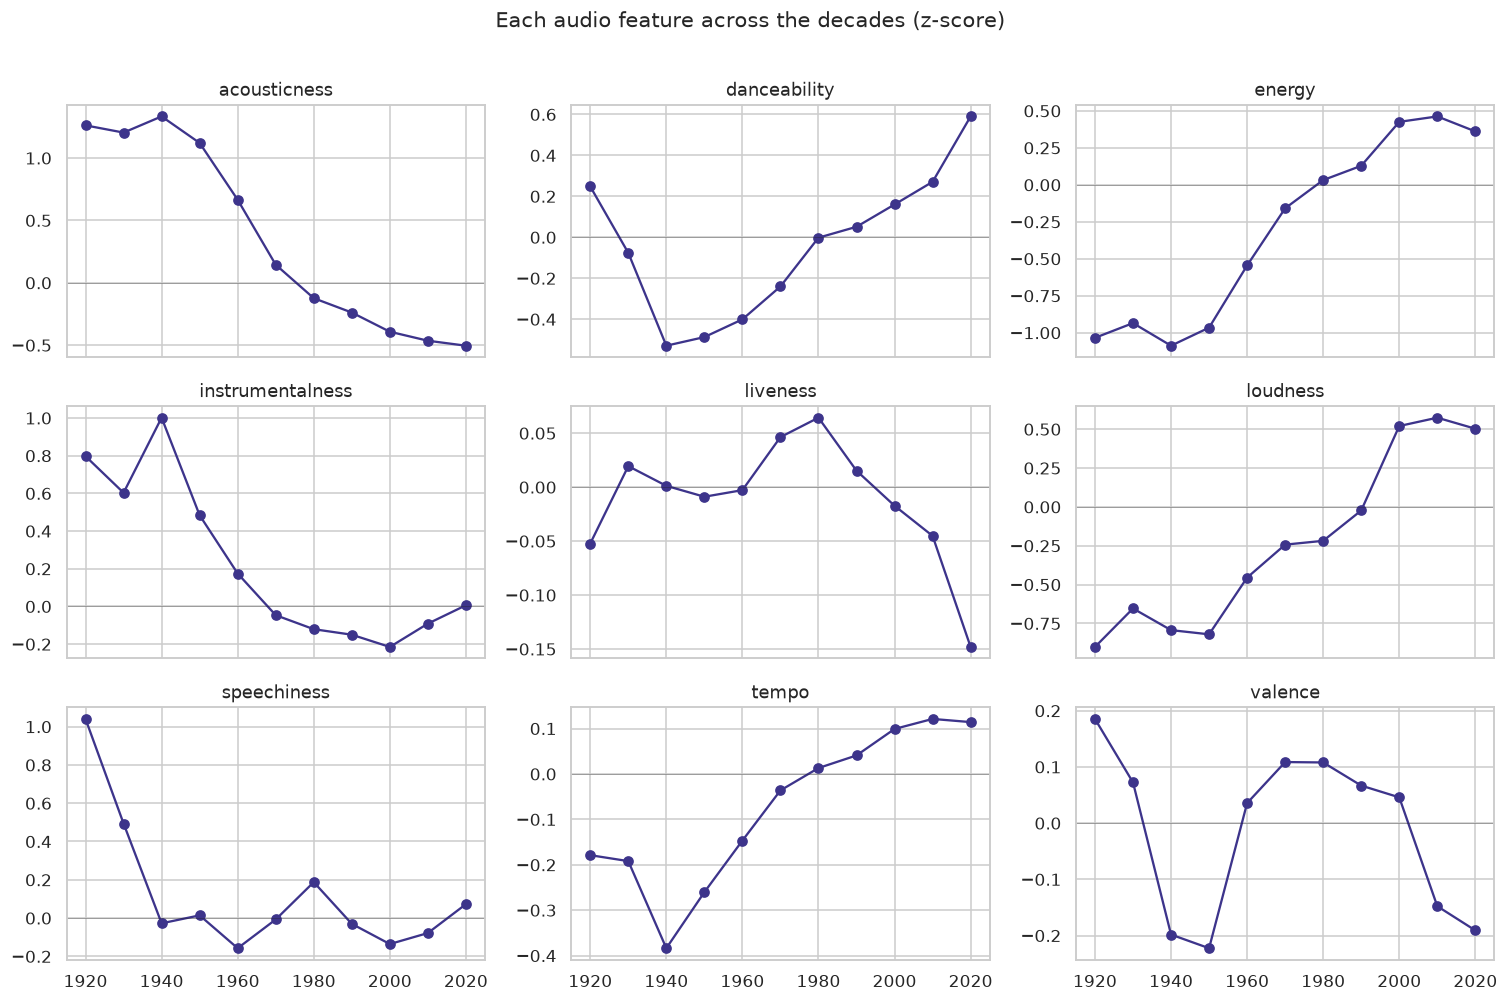

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=True)
for ax, f in zip(axes.ravel(), AUDIO):
    ax.plot(by_decade.index, by_decade[f], marker='o', color='#3d348b')
    ax.axhline(0, color='k', lw=.5, alpha=.4); ax.set_title(f)
fig.suptitle('Each audio feature across the decades (z-score)', y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

## Step 3 — Does the past recur? (decade-similarity matrix)
Similarity between each pair of decade centroids. If music were cyclical, non-adjacent decades would light up (bright off-diagonal). If it just drifts, we'll see a diagonal band that fades with distance.

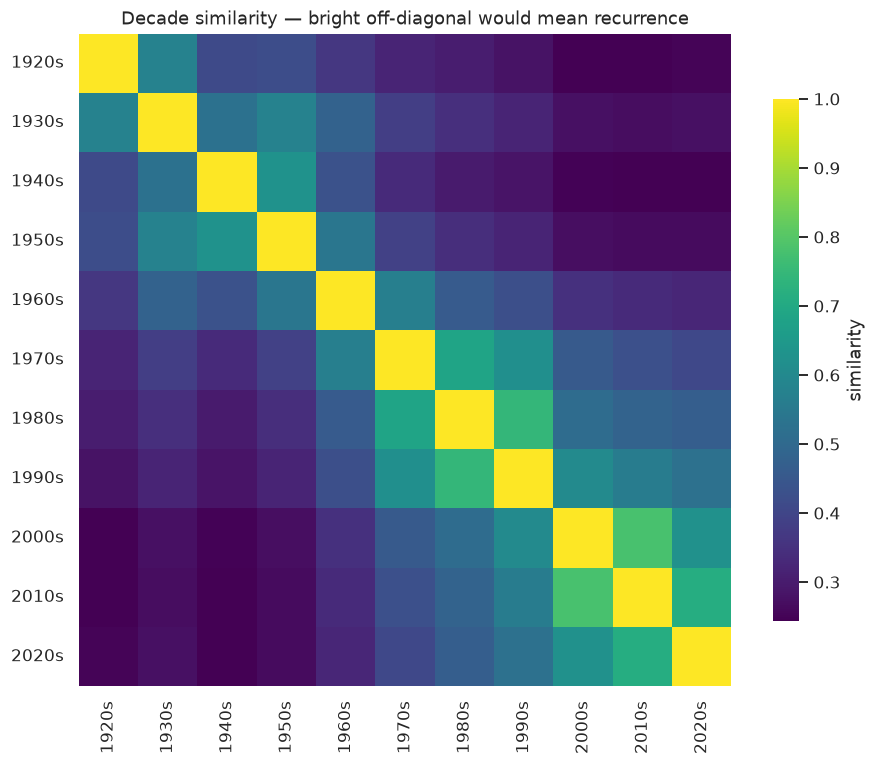

In [4]:
from scipy.spatial.distance import pdist, squareform
C = by_decade.to_numpy()
D = squareform(pdist(C))
sim = 1/(1+D)
labs = [f'{d}s' for d in by_decade.index]
plt.figure(figsize=(8.5, 7))
sns.heatmap(sim, xticklabels=labs, yticklabels=labs, cmap='viridis', square=True,
            cbar_kws={'label': 'similarity', 'shrink': .8})
plt.title('Decade similarity — bright off-diagonal would mean recurrence')
plt.tight_layout(); plt.show()

In [5]:
decs = by_decade.index.to_numpy()
print('Which earlier, non-adjacent decade does each most resemble?')
for i, d in enumerate(decs):
    older = [(decs[j], D[i, j]) for j in range(i-1)]
    if older:
        best = min(older, key=lambda t: t[1])
        print(f'  {d}s -> {best[0]}s (dist {best[1]:.2f})')

Which earlier, non-adjacent decade does each most resemble?
  1940s -> 1920s (dist 1.41)
  1950s -> 1930s (dist 0.74)
  1960s -> 1930s (dist 1.09)
  1970s -> 1950s (dist 1.56)
  1980s -> 1960s (dist 1.19)
  1990s -> 1970s (dist 0.62)
  2000s -> 1980s (dist 0.96)
  2010s -> 1990s (dist 0.79)
  2020s -> 2000s (dist 0.61)


## Verdict
**Music is a one-way river, not a cycle.** The matrix is a strong diagonal band that fades with distance; the 2010s corner and the 1950s corner are dark. Each decade most resembles its *immediate* neighbors — no fashion-style return. The honest answer *refutes* the hypothesis, which is itself a clean, visual story.